## Instalação das bibliotecas necessárias

Nesta etapa instalamos as bibliotecas que serão utilizadas na atividade.

Usaremos:

- **sentence-transformers** → biblioteca que fornece modelos de embeddings prontos, como o SBERT.
- **scikit-learn** → biblioteca usada para calcular similaridade entre vetores.
- **matplotlib** → biblioteca para visualização gráfica.


In [ ]:
!pip install -q sentence-transformers scikit-learn matplotlib

## Carregando um modelo de embeddings

Aqui carregamos um modelo pré-treinado chamado:

**all-MiniLM-L6-v2**

Esse modelo pertence à família **Sentence-BERT (SBERT)**, que foi projetada para gerar embeddings de frases.


In [ ]:
from sentence_transformers import SentenceTransformer

# Small and fast SBERT model
model = SentenceTransformer("all-MiniLM-L6-v2")

print("**********Model loaded!**********")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


**********Model loaded!**********


## Criando frases de exemplo

Agora definimos algumas frases que serão usadas para gerar embeddings.

Essas frases foram escolhidas para representar dois temas diferentes:

• Inteligência Artificial / Machine Learning  
• Animais

Modelos de embeddings devem capturar **similaridade semântica**, ou seja:

frases com significados parecidos devem produzir vetores semelhantes.


In [ ]:
sentences = [
    "I love studying artificial intelligence",
    "Machine learning is fascinating",
    "Dogs are playing in the park",
    "The car is yellow",
    "The dogs are eating too much.",
    "Deep learning is a part of AI",
]

sentences

['I love studying artificial intelligence',
 'Machine learning is fascinating',
 'Dogs are playing in the park',
 'The car is yellow',
 'The dogs are eating too much.',
 'Deep learning is a part of AI']

## Gerando embeddings

Nesta etapa transformamos as frases em **embeddings**.

Embeddings são vetores numéricos que representam o significado de um texto.

No Capítulo 10 aprendemos que esses vetores existem em um **espaço vetorial de alta dimensão**, onde:

- textos semelhantes ficam próximos
- textos diferentes ficam distantes

In [ ]:
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

Embedding shape: (6, 384)


## Calculando similaridade semântica

Agora vamos medir o quão parecidas as frases são entre si.

Para isso utilizamos **cosine similarity**, uma métrica que mede o ângulo entre dois vetores.

O valor varia entre:

- **1 → muito semelhantes**
- **0 → sem relação**
- **-1 → opostos**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

similarity_matrix = cosine_similarity(embeddings)

pd.DataFrame(similarity_matrix, columns=sentences, index=sentences)

,I love studying artificial intelligence,Machine learning is fascinating,Dogs are playing in the park,The car is yellow,The dogs are eating too much.,Deep learning is a part of AI
I love studying artificial intelligence,1.000000,0.566226,0.007344,0.003744,-0.003705,0.532921
Machine learning is fascinating,0.566226,1.000000,0.012215,0.012101,-0.021890,0.597062
Dogs are playing in the park,0.007344,0.012215,1.000000,0.004243,0.415701,0.008974
The car is yellow,0.003744,0.012101,0.004243,1.000000,-0.009820,-0.041618
The dogs are eating too much.,-0.003705,-0.021890,0.415701,-0.009820,1.000000,-0.025584
Deep learning is a part of AI,0.532921,0.597062,0.008974,-0.041618,-0.025584,1.000000


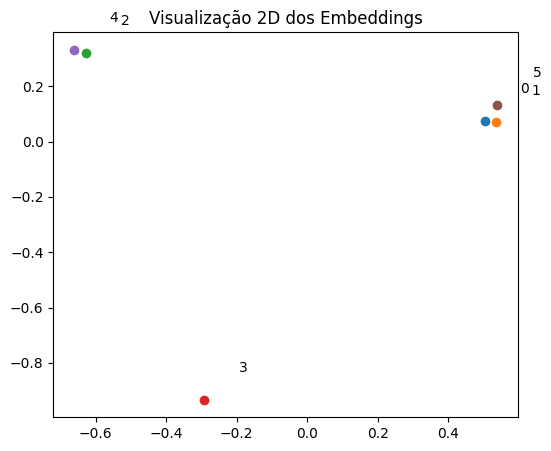

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(6,5))

for i, sentence in enumerate(sentences):
    x, y = embeddings_2d[i]
    plt.scatter(x, y)
    plt.text(x+0.1, y+0.1, str(i))

plt.title("Visualização 2D dos Embeddings")
plt.show()

In [ ]:
positive_pair = [
    "I love artificial intelligence",
    "Artificial intelligence is fascinating"
]

negative_pair = [
    "I love artificial intelligence",
    "Dogs are playing in the park"
]

# gerar embeddings
positive_embeddings = model.encode(positive_pair)
negative_embeddings = model.encode(negative_pair)

# calcular similaridade
positive_similarity = cosine_similarity([positive_embeddings[0]], [positive_embeddings[1]])
negative_similarity = cosine_similarity([negative_embeddings[0]], [negative_embeddings[1]])

print("Similaridade (par positivo):", positive_similarity[0][0])
print("Similaridade (par negativo):", negative_similarity[0][0])

Similaridade (par positivo): 0.8264115
Similaridade (par negativo): 0.014638811


## Exercício: testando o modelo

Agora vamos testar o modelo com **novas frases**.

Geraremos embeddings para essas frases e compararemos com as frases originais.

O objetivo é verificar se o modelo consegue identificar corretamente qual frase pertence a cada grupo semântico.


In [ ]:
new_sentences = [
    "Artificial intelligence helps solve complex problems",
    "Puppies are running in the park"
]

new_embeddings = model.encode(new_sentences)

similarity = cosine_similarity(new_embeddings, embeddings)

pd.DataFrame(similarity, columns=sentences, index=new_sentences)

,I love studying artificial intelligence,Machine learning is fascinating,Dogs are playing in the park,Cats are sleeping on the sofa,Deep learning is a part of AI
,0.08415,0.143651,0.006267,-0.067067,0.07287
,0.08415,0.143651,0.006267,-0.067067,0.07287


## Visualizando embeddings em 2D

Os embeddings possuem **384 dimensões**, o que dificulta a visualização direta.

Para resolver isso usamos **PCA (Principal Component Analysis)**, uma técnica de redução de dimensionalidade.

O PCA reduz os vetores para **2 dimensões**, permitindo que possamos visualizá-los em um gráfico.

Se o modelo capturou corretamente o significado das frases, frases com temas semelhantes devem aparecer **próximas umas das outras no gráfico**.

In [ ]:
test_sentences = [
    "I enjoy learning about neural networks",
    "Artificial intelligence is changing the world",
    "A group of dogs is running outside",
    "The red car is parked on the street"
]

# Gere os embeddings
test_embeddings = model.encode(test_sentences)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

# Reduza os embeddings para 2 dimensões
embeddings_2d = pca.fit_transform(test_embeddings)

plt.figure(figsize=(6,5))

for i, sentence in enumerate(test_sentences):
    x, y = embeddings_2d[i]
    plt.scatter(x, y)
    plt.text(x+0.1, y+0.1, str(i))

plt.title("Visualização dos embeddings criados:")
plt.show()

## Questão Teórica — Verdadeiro ou Falso

Com base no que foi visto sobre **text embeddings e similaridade semântica**, marque **V (Verdadeiro)** ou **F (Falso)** para cada afirmação.

1. Modelos de embeddings transformam textos em vetores numéricos que representam o significado das frases.

2. A função `model.encode()` retorna diretamente o valor de similaridade entre duas frases.

3. Quanto maior a distância entre dois embeddings, mais semelhantes são os textos.

4. Técnicas como PCA podem ser usadas para reduzir a dimensionalidade dos embeddings para facilitar a visualização.

5. Embeddings são representações de texto formadas apenas por palavras do próprio texto original.

Resposta: